# Probabilistic Embeddings for Clustering: CIFAR-100 Experiments

## Three Probabilistic Embedding Models

All three models share the same CNN backbone (Phase 1: contrastive training).
They differ only in how they produce **predictive variance**:

| Model | Variance Source | Mechanism | Extra Training |
| :--- | :--- | :--- | :--- |
| **CNN + LLA** | Post-hoc Bayesian | Laplace last-layer KFAC | 0 extra epochs (analytic) |
| **UG (identity)** | Trained variance (identity $K$) | Diagonal variance network | Phase 2 |
| **UG (adaptive)** | Trained variance (adaptive $K$) | Full adaptive variance network | Phase 2 |

## Experiments

| Experiment | What it tests | Key metric |
| :--- | :--- | :--- |
| **Exp 1**: KMedoid cluster estimation | Cluster quality with oracle $k$, count high-quality clusters | $N(\tau)$ = # classes with F1 $> \tau$ |
| **Exp 2**: Chimera inputs | Embed half-and-half images (2 classes), inspect position & variance | Embedding position, total variance |

In [22]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                             accuracy_score, f1_score)

from datasets.image_contrastive import ImageContrastiveDataset
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from features.image import DeepCNNFeatureExtractor
from train import train_contrastive
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
from metrics.similarity import compute_pairwise_probabilistic_similarity

SEED = 26042024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda


## Configuration & Data Loading

In [23]:
# --- Experiment configuration ---
N_CLASSES = 20           # Number of classes for training
DIM = 128                # Embedding dimension
EPOCHS = 200             # CNN contrastive training epochs
UG_P2_EPOCHS = 50        # UncertainGen phase 2 (variance) epochs
LR = 0.001
BATCH_SIZE = 256
NEG_PER_POS = 20         # Negative samples per positive pair
NUM_WORKERS = 0          # DataLoader workers (0 for Windows compatibility)
MAX_TRAIN = 0            # 0 = use all available training samples

# Save/load
MODEL_DIR = "../../models/cifar100"
LOAD_MODELS = True
SAVE_MODELS = True
os.makedirs(MODEL_DIR, exist_ok=True)

def make_backbone():
    """Create the shared 4-layer CNN backbone."""
    return DeepCNNFeatureExtractor(
        in_channels=3, image_size=32, output_dim=512,
        channels=[32, 64, 128, 256],
    )

# Randomly select classes (deterministic via seed)
rng = np.random.RandomState(SEED)
all_classes = list(range(100))
rng.shuffle(all_classes)
KNOWN_CLASSES = sorted(all_classes[:N_CLASSES])
print(f"Known classes ({N_CLASSES}): {KNOWN_CLASSES}")

Known classes (20): [3, 7, 9, 16, 17, 18, 23, 36, 37, 39, 42, 50, 51, 53, 62, 78, 83, 92, 93, 97]


In [24]:
# Load contrastive training set (known classes only, oracle pairing)
train_ds = ImageContrastiveDataset(
    dataset_name="cifar100", split="train",
    neg_sample_per_pos=NEG_PER_POS, max_samples=MAX_TRAIN,
    data_root="../../data", seed=SEED,
    class_subset=KNOWN_CLASSES,
)

# Load CIFAR-100 test set via torchvision
import torchvision, torchvision.transforms as T
cifar100_test = torchvision.datasets.CIFAR100(
    root="../../data", train=False, download=True, transform=T.ToTensor()
)

def load_test_subset(classes):
    """Load flattened images and labels for a subset of CIFAR-100 test classes."""
    class_set = set(classes)
    indices = [i for i in range(len(cifar100_test)) if cifar100_test.targets[i] in class_set]
    images = np.array([cifar100_test[i][0].reshape(-1).numpy() for i in indices])
    labels = np.array([cifar100_test.targets[i] for i in indices])
    return images, labels

test_images, test_labels = load_test_subset(KNOWN_CLASSES)
print(f"Train: {len(train_ds)} samples, feature_dim={train_ds.feature_dim}")
print(f"Test (known): {len(test_images)} samples, {len(KNOWN_CLASSES)} classes")

# Load CIFAR-100 train set for KMedoid threshold calibration (reference data)
cifar100_train_raw = torchvision.datasets.CIFAR100(
    root="../../data", train=True, download=True, transform=T.ToTensor()
)

def load_train_subset(classes):
    """Load flattened images and labels for a subset of CIFAR-100 train classes."""
    class_set = set(classes)
    indices = [i for i in range(len(cifar100_train_raw)) if cifar100_train_raw.targets[i] in class_set]
    images = np.array([cifar100_train_raw[i][0].reshape(-1).numpy() for i in indices])
    labels = np.array([cifar100_train_raw.targets[i] for i in indices])
    return images, labels

train_images, train_labels = load_train_subset(KNOWN_CLASSES)
print(f"Train (reference): {len(train_images)} samples, {len(set(train_labels.tolist()))} classes")

 Loading cifar100 (train) │██████████████████████████████│ 10000/10000 [00:01<00:00]


Dataset loaded: 10000 samples, feature_dim=3072, classes=20, pairing=pos=oracle (label), neg=random (non-strict)
Train: 10000 samples, feature_dim=3072
Test (known): 2000 samples, 20 classes
Train (reference): 10000 samples, 20 classes


## Model Training

**Phase 1**: Train a deterministic CNN with contrastive loss (shared by all 3 models).  
**Phase 2**: Train variance networks (UG-I, UG-A) with frozen mean, or fit LLA post-hoc.

In [25]:
# --- Model save/load paths ---
CNN_PATH = os.path.join(MODEL_DIR, "cnn.model")
UGI_PATH = os.path.join(MODEL_DIR, "ug_identity.model")
UGA_PATH = os.path.join(MODEL_DIR, "ug_adaptive.model")
CNN_LOSS_PATH = os.path.join(MODEL_DIR, "cnn_loss.npy")
UGI_LOSS_P2_PATH = os.path.join(MODEL_DIR, "ugi_loss_p2.npy")
UGA_LOSS_P2_PATH = os.path.join(MODEL_DIR, "uga_loss_p2.npy")

In [26]:
# --- Phase 1: CNN (deterministic contrastive) ---
cnn_backbone = make_backbone()

if LOAD_MODELS and os.path.exists(CNN_PATH):
    model_cnn = NonLinearEmbedder.load(CNN_PATH, device=DEVICE, feature_extractor=cnn_backbone)
    loss_cnn = list(np.load(CNN_LOSS_PATH))
    print(f"CNN loaded from {CNN_PATH}")
else:
    set_seed(SEED)
    model_cnn = NonLinearEmbedder(feature_extractor=cnn_backbone, dim=DIM, device=DEVICE, seed=SEED)
    loss_cnn = train_contrastive(
        model=model_cnn, dataset=train_ds, loss_fn=contrastive_loss,
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_cnn.save(CNN_PATH)
        np.save(CNN_LOSS_PATH, np.array(loss_cnn))
    print("CNN training done.")
print(f"  Final loss: {loss_cnn[-1]:.4f}")

CNN loaded from ../models/cifar100\cnn.model
  Final loss: 0.0712


In [27]:
# --- Phase 2a: UncertainGen Identity ---
ugi_backbone = make_backbone()

if LOAD_MODELS and os.path.exists(UGI_PATH):
    model_ugi = UncertainGenEmbedder.load(UGI_PATH, device=DEVICE, feature_extractor=ugi_backbone)
    loss_ugi_p2 = list(np.load(UGI_LOSS_P2_PATH))
    print(f"UG-I loaded from {UGI_PATH}")
else:
    set_seed(SEED)
    model_ugi = UncertainGenEmbedder(
        feature_extractor=ugi_backbone, dim=DIM, k_form="identity",
        device=DEVICE, seed=SEED,
    )
    model_ugi.copy_mean_from(model_cnn)
    print("UG-I: Copied mean network from CNN")
    loss_ugi_p2 = train_variance_phase(
        model=model_ugi, dataset=train_ds,
        lr=LR, epochs=UG_P2_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_ugi.save(UGI_PATH)
        np.save(UGI_LOSS_P2_PATH, np.array(loss_ugi_p2))
    print("UG-I training done.")
print(f"  Final P2 loss: {loss_ugi_p2[-1]:.4f}")

UG-I loaded from ../models/cifar100\ug_identity.model
  Final P2 loss: 0.0765


In [28]:
# --- Phase 2b: UncertainGen Adaptive ---
uga_backbone = make_backbone()

if LOAD_MODELS and os.path.exists(UGA_PATH):
    model_uga = UncertainGenEmbedder.load(UGA_PATH, device=DEVICE, feature_extractor=uga_backbone)
    loss_uga_p2 = list(np.load(UGA_LOSS_P2_PATH))
    print(f"UG-A loaded from {UGA_PATH}")
else:
    set_seed(SEED)
    model_uga = UncertainGenEmbedder(
        feature_extractor=uga_backbone, dim=DIM, k_form="adaptive",
        device=DEVICE, seed=SEED,
    )
    model_uga.copy_mean_from(model_cnn)
    print("UG-A: Copied mean network from CNN")
    loss_uga_p2 = train_variance_phase(
        model=model_uga, dataset=train_ds,
        lr=LR, epochs=UG_P2_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_uga.save(UGA_PATH)
        np.save(UGA_LOSS_P2_PATH, np.array(loss_uga_p2))
    print("UG-A training done.")
print(f"  Final P2 loss: {loss_uga_p2[-1]:.4f}")

UG-A loaded from ../models/cifar100\ug_adaptive.model
  Final P2 loss: 0.0766


In [29]:
# --- Post-hoc: LLA (KFAC on trained CNN, zero extra epochs) ---
print("Fitting LLA on CNN...")
lla_cnn = LaplaceLastLayerEmbedder(model_cnn, prior_precision=1.0)
lla_cnn.fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
lla_cnn.optimize_prior(method="cv", calibration_data=train_images)

Fitting LLA on CNN...


 LLA fit │██████████████████████████████│ 157/157 [00:05<00:00]


LLA fitted on 420000 samples (B: GGN).
  S_A range: [1.00e-06, 4.34e+01]
  S_B range: [9.52e-02, 5.19e-01]
  CV-optimized prior: tau=0.2653 (CV=0.5165)


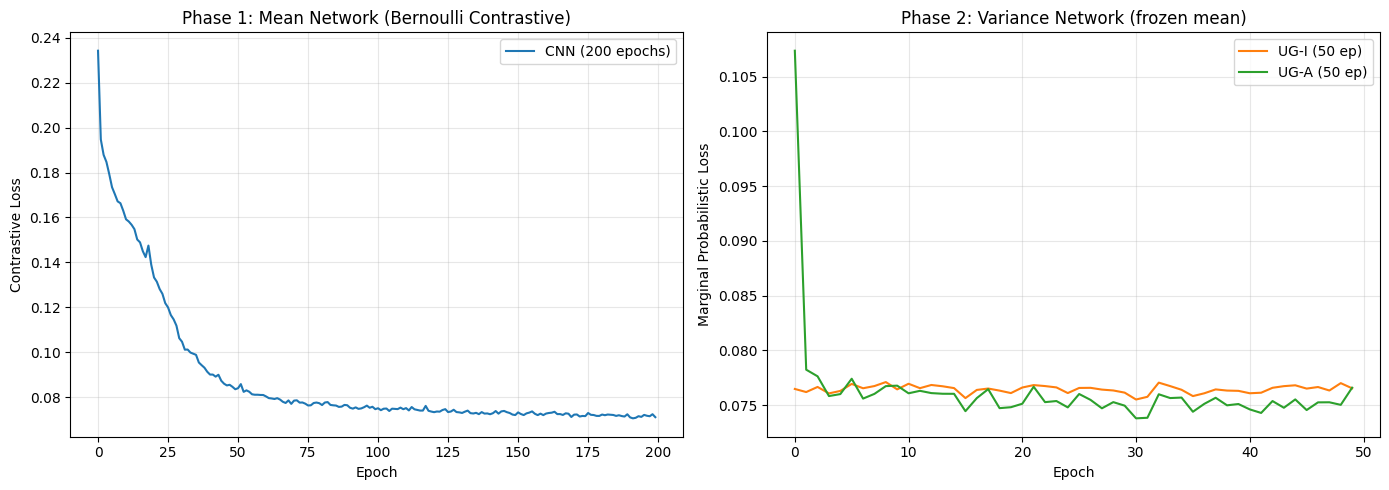

In [30]:
# --- Training Loss Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss_cnn, linewidth=1.5, color="C0", label=f"CNN ({len(loss_cnn)} epochs)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Contrastive Loss")
axes[0].set_title("Phase 1: Mean Network (Bernoulli Contrastive)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_ugi_p2, linewidth=1.5, color="C1", label=f"UG-I ({len(loss_ugi_p2)} ep)")
axes[1].plot(loss_uga_p2, linewidth=1.5, color="C2", label=f"UG-A ({len(loss_uga_p2)} ep)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Marginal Probabilistic Loss")
axes[1].set_title("Phase 2: Variance Network (frozen mean)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Embedding & Calibration

In [31]:
# --- Embed test set and training set (reference) with all 3 models ---
emb_lla = lla_cnn.embed(test_images)
emb_ugi = model_ugi.embed(test_images)
emb_uga = model_uga.embed(test_images)

all_embs = [
    ("LLA", emb_lla),
    ("UG-I", emb_ugi),
    ("UG-A", emb_uga),
]

for name, emb in all_embs:
    print(f"{name:6s}  mean {emb.mean.shape}, var {emb.variance.shape}")

# --- Embed training data (reference for KMedoid threshold computation) ---
train_emb_lla = lla_cnn.embed(train_images)
train_emb_ugi = model_ugi.embed(train_images)
train_emb_uga = model_uga.embed(train_images)

all_train_embs = [
    ("LLA", train_emb_lla),
    ("UG-I", train_emb_ugi),
    ("UG-A", train_emb_uga),
]

print("\nTraining embeddings (reference):")
for name, emb in all_train_embs:
    print(f"{name:6s}  mean {emb.mean.shape}, var {emb.variance.shape}")

LLA     mean (2000, 128), var (2000, 128)
UG-I    mean (2000, 128), var (2000, 128)
UG-A    mean (2000, 128), var (2000, 128)

Training embeddings (reference):
LLA     mean (10000, 128), var (10000, 128)
UG-I    mean (10000, 128), var (10000, 128)
UG-A    mean (10000, 128), var (10000, 128)


### Mahalanobis Scale Calibration

The Mahalanobis scale converts raw probabilistic distances to similarities via $\text{sim} = \exp(-s \cdot d_{\text{Mahal}})$. The scale $s$ is chosen so that the median intra-class Mahalanobis distance maps to a target similarity of 0.5:

$$s = \frac{-\ln(0.5)}{\text{median}(d)} = \frac{\ln 2}{\text{median}(d)}$$

Models with very large raw Mahalanobis distances (e.g., UG-I with median ~46k) get extremely small scale values, while models with small raw distances get large scale values. This auto-calibration ensures all models operate on comparable similarity ranges.

In [32]:
# --- Compute per-model Mahalanobis scale from training data ---
TARGET_SIM = 0.5

mahal_scales = {}

for name, train_emb in all_train_embs:
    means = train_emb.mean.astype(np.float32)
    variances = train_emb.variance.astype(np.float32)

    unique_cls = np.unique(train_labels)
    raw_mahals = []
    for c in unique_cls:
        mask = train_labels == c
        cls_mean = means[mask].mean(axis=0)
        cls_var = variances[mask].mean(axis=0)
        delta = means[mask] - cls_mean
        cvar = variances[mask] + cls_var
        mahal = np.sum(delta**2 / cvar, axis=1)
        raw_mahals.append(mahal)
    raw_mahals = np.concatenate(raw_mahals)

    median_mahal = np.median(raw_mahals)
    if median_mahal > 0:
        scale = -np.log(TARGET_SIM) / median_mahal
    else:
        scale = 0.25

    mahal_scales[name] = scale
    print(f"{name:6s}  median_raw_mahal={median_mahal:8.2f}  "
          f"scale={scale:.6f}  (paper default: 0.25)")

print(f"\nPer-model scales: {mahal_scales}")

LLA     median_raw_mahal=   13.34  scale=0.051944  (paper default: 0.25)
UG-I    median_raw_mahal=46262.29  scale=0.000015  (paper default: 0.25)
UG-A    median_raw_mahal=    0.63  scale=1.095535  (paper default: 0.25)

Per-model scales: {'LLA': 0.051943585107588466, 'UG-I': 1.4982984945330067e-05, 'UG-A': 1.0955350042218837}


---

## Experiment 1: Cluster Estimation & High-Quality Clusters

### Motivation

In metagenomics, the number of species in a sample is **unknown**. The KMedoid algorithm
from the paper estimates $k$ automatically using similarity thresholding.

### Evaluation: Counting High-Quality Clusters

After Hungarian alignment between predicted clusters and true classes, we compute per-class
F1 and count how many classes exceed each threshold:

$$N(\tau) = \#\{k : \text{F1}_k > \tau\}$$

The headline metric is $N(0.5)$ — the number of classes with F1 $> 0.5$.

In [33]:
# --- Evaluation utilities ---

def paper_metric(true_labels, pred_labels, thresholds=None):
    """Compute paper-style metric: # clusters with F1 > tau after Hungarian alignment."""
    return count_high_quality_clusters(true_labels, pred_labels, thresholds)

def score_clustering(pred, true_labels):
    """Score clustering with standard metrics."""
    mask = pred != -1
    n_assigned = mask.sum()
    if n_assigned == 0:
        return {"acc": 0, "nmi": 0, "ari": 0, "f1": 0, "k": 0, "coverage": 0.0}
    label_map = align_labels_via_hungarian_algorithm(true_labels[mask], pred[mask])
    aligned = np.array([label_map.get(p, p) for p in pred[mask]])
    return {
        "acc": accuracy_score(true_labels[mask], aligned),
        "nmi": normalized_mutual_info_score(true_labels[mask], pred[mask]),
        "ari": adjusted_rand_score(true_labels[mask], pred[mask]),
        "f1": f1_score(true_labels[mask], aligned, average="macro"),
        "k": len(set(pred[mask].tolist())),
        "coverage": n_assigned / len(true_labels),
    }

In [34]:
true_k = len(KNOWN_CLASSES)
print(f"True k = {true_k}")
print("=" * 80)

# --- KMedoids Clustering (sklearn_extra, oracle k, probabilistic distance) ---
print(f"\n=== KMedoids Clustering (sklearn_extra, k={true_k}) ===")
print(f"{'Model':8s}  {'Scale':>8s}  {'F1>0.3':>6s}  {'F1>0.5':>6s}  "
      f"{'F1>0.7':>6s}  {'F1>0.9':>6s}  {'Acc':>6s}")
print("-" * 60)

kmedoid_results = {}
for name, emb in all_embs:
    ms = mahal_scales.get(name, 0.25)
    means = emb.mean.astype(np.float32)
    variances = emb.variance.astype(np.float32)
    if variances.ndim == 3:
        variances = np.diagonal(variances, axis1=1, axis2=2)

    # Probabilistic similarity -> distance
    sim = compute_pairwise_probabilistic_similarity(means, variances, scale=ms)
    dist = 1.0 - sim

    kmed = KMedoids(n_clusters=true_k, metric="precomputed",
                    random_state=SEED, method="pam")
    pred = kmed.fit_predict(dist)

    r = paper_metric(test_labels, pred)
    sc = score_clustering(pred, test_labels)
    cov = r["n_assigned"] / max(r["n_total"], 1)
    kmedoid_results[name] = {"pred": pred, "result": r, "cov": cov, "k": true_k,
                             "scores": sc}
    print(f"{name:8s}  {ms:8.4f}  {r['counts'][2]:6d}  {r['counts'][4]:6d}  "
          f"{r['counts'][6]:6d}  {r['counts'][8]:6d}  {sc['acc']:6.3f}")

# --- Baseline: K-Means with oracle k ---
print(f"\n=== K-Means Baseline (k={true_k}, oracle) ===")
print(f"{'Model':8s}  {'F1>0.3':>6s}  {'F1>0.5':>6s}  {'F1>0.7':>6s}  {'F1>0.9':>6s}  {'Acc':>6s}")
print("-" * 55)
# All 3 models share the same mean network, so K-Means gives identical results
km = KMeans(n_clusters=true_k, random_state=SEED, n_init=10)
pred_km = km.fit_predict(emb_lla.mean)  # any model's mean works (all identical)
r_km = paper_metric(test_labels, pred_km)
sc_km = score_clustering(pred_km, test_labels)
print(f"{'All':8s}  {r_km['counts'][2]:6d}  {r_km['counts'][4]:6d}  "
      f"{r_km['counts'][6]:6d}  {r_km['counts'][8]:6d}  {sc_km['acc']:6.3f}")

print("\nNote: K-Means uses only .mean (identical across all models).")
print("KMedoids uses probabilistic Mahalanobis distance -> different results per model.")

True k = 20

=== KMedoids Clustering (sklearn_extra, k=20) ===
Model        Scale  F1>0.3  F1>0.5  F1>0.7  F1>0.9     Acc
------------------------------------------------------------


 Computing probabilistic similarity │██████████████████████████████│ 4/4 [00:02<00:00]


LLA         0.0519      19       9       3       0   0.492


 Computing probabilistic similarity │██████████████████████████████│ 4/4 [00:02<00:00]


UG-I        0.0000      12       6       0       0   0.317


 Computing probabilistic similarity │██████████████████████████████│ 4/4 [00:02<00:00]


UG-A        1.0955      19      14       3       0   0.532

=== K-Means Baseline (k=20, oracle) ===
Model     F1>0.3  F1>0.5  F1>0.7  F1>0.9     Acc
-------------------------------------------------------
All           20      14       3       0   0.555

Note: K-Means uses only .mean (identical across all models).
KMedoids uses probabilistic Mahalanobis distance -> different results per model.


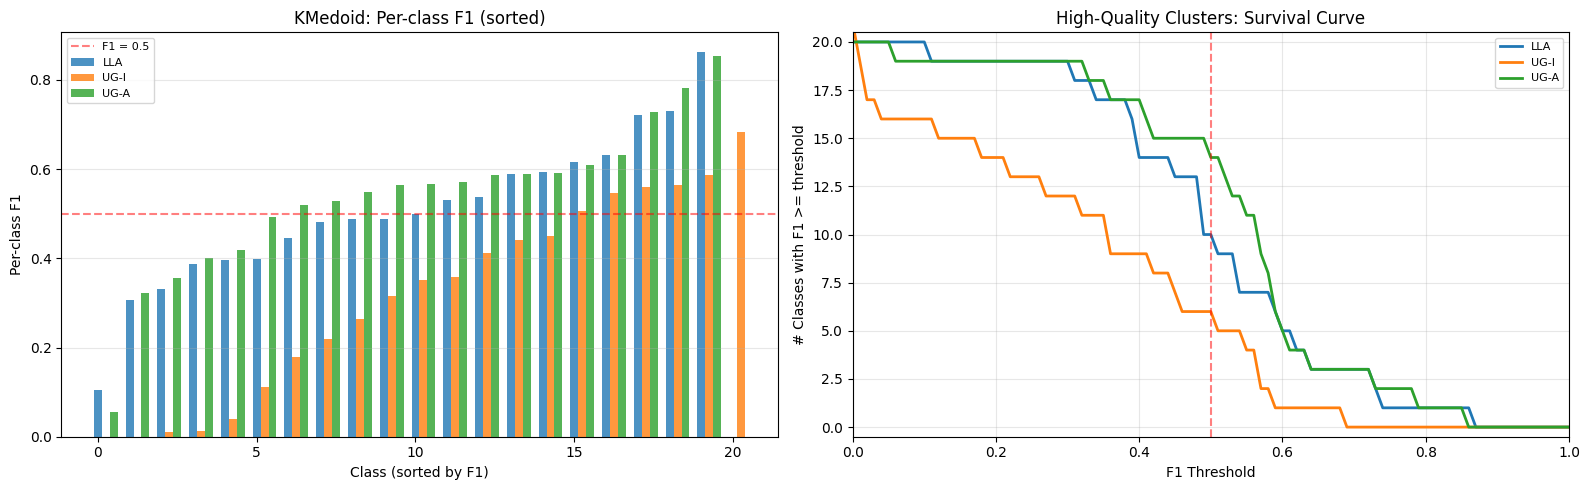

In [35]:
# --- Per-class F1 breakdown ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {"LLA": "C0", "UG-I": "C1", "UG-A": "C2"}

# Left: Per-class F1 bar chart for KMedoid
ax = axes[0]
for name in ["LLA", "UG-I", "UG-A"]:
    r = kmedoid_results[name]["result"]
    per_f1 = r["per_class_f1"]
    ax.bar(np.arange(len(per_f1)) + list(colors.keys()).index(name) * 0.25,
           per_f1, 0.25, label=name, color=colors[name], alpha=0.8)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="F1 = 0.5")
ax.set_xlabel("Class (sorted by F1)")
ax.set_ylabel("Per-class F1")
ax.set_title("KMedoid: Per-class F1 (sorted)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# Right: Survival curve (# classes with F1 >= threshold)
ax = axes[1]
thresholds = np.linspace(0, 1, 101)
for name in ["LLA", "UG-I", "UG-A"]:
    r = kmedoid_results[name]["result"]
    per_f1 = r["per_class_f1"]
    counts = [np.sum(per_f1 >= t) for t in thresholds]
    ax.plot(thresholds, counts, linewidth=2, label=name, color=colors[name])
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("F1 Threshold")
ax.set_ylabel("# Classes with F1 >= threshold")
ax.set_title("High-Quality Clusters: Survival Curve")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, true_k + 0.5)

plt.tight_layout()
plt.show()

---

## Experiment 2: Chimera Inputs (Inter-Class Mixtures)

### Motivation

In metagenomics, **chimeric reads** arise when sequencing errors join fragments from two
different organisms. These ambiguous inputs should ideally produce **higher predictive
variance** and land **between** the two source clusters in embedding space.

### Setup

For each pair of selected classes $(A, B)$:
1. Take one example image from class $A$ and one from class $B$
2. Create a **chimera**: top half from $A$, bottom half from $B$ (CIFAR-100: 32x32x3)
3. Embed the chimera with each model
4. Measure:
   - **Position**: distance to class $A$ and class $B$ centers
   - **Variance**: total predictive variance vs. typical intra-class variance

In [36]:
# --- Build chimeric images ---
# CIFAR-100 images are 3x32x32 = 3072 flattened. We split at the midpoint (row 16).
IMG_C, IMG_H, IMG_W = 3, 32, 32
HALF_H = IMG_H // 2

def make_chimera(img_a, img_b):
    """Create a chimeric image: top half from img_a, bottom half from img_b.
    Both inputs are flattened (3072,) vectors in CHW order."""
    a = img_a.reshape(IMG_C, IMG_H, IMG_W)
    b = img_b.reshape(IMG_C, IMG_H, IMG_W)
    chimera = np.concatenate([a[:, :HALF_H, :], b[:, HALF_H:, :]], axis=1)
    return chimera.reshape(-1)

# Select class pairs for the chimera experiment
# Use 5 random pairs from the known classes
rng_chimera = np.random.RandomState(SEED + 42)
N_PAIRS = 5
unique_classes = np.unique(test_labels)
class_pairs = []
for _ in range(N_PAIRS):
    pair = rng_chimera.choice(unique_classes, size=2, replace=False)
    class_pairs.append(tuple(sorted(pair)))

# For each pair, create chimeras from multiple example combinations
N_EXAMPLES_PER_PAIR = 10  # number of chimeras per class pair
chimera_images = []
chimera_class_a = []
chimera_class_b = []

for cls_a, cls_b in class_pairs:
    idx_a = np.where(test_labels == cls_a)[0]
    idx_b = np.where(test_labels == cls_b)[0]
    for i in range(N_EXAMPLES_PER_PAIR):
        ia = idx_a[rng_chimera.randint(len(idx_a))]
        ib = idx_b[rng_chimera.randint(len(idx_b))]
        chimera_images.append(make_chimera(test_images[ia], test_images[ib]))
        chimera_class_a.append(cls_a)
        chimera_class_b.append(cls_b)

chimera_images = np.array(chimera_images)
chimera_class_a = np.array(chimera_class_a)
chimera_class_b = np.array(chimera_class_b)
print(f"Created {len(chimera_images)} chimeric images from {N_PAIRS} class pairs")
print(f"Class pairs: {class_pairs}")

Created 50 chimeric images from 5 class pairs
Class pairs: [(39, 92), (17, 39), (78, 97), (78, 92), (42, 93)]


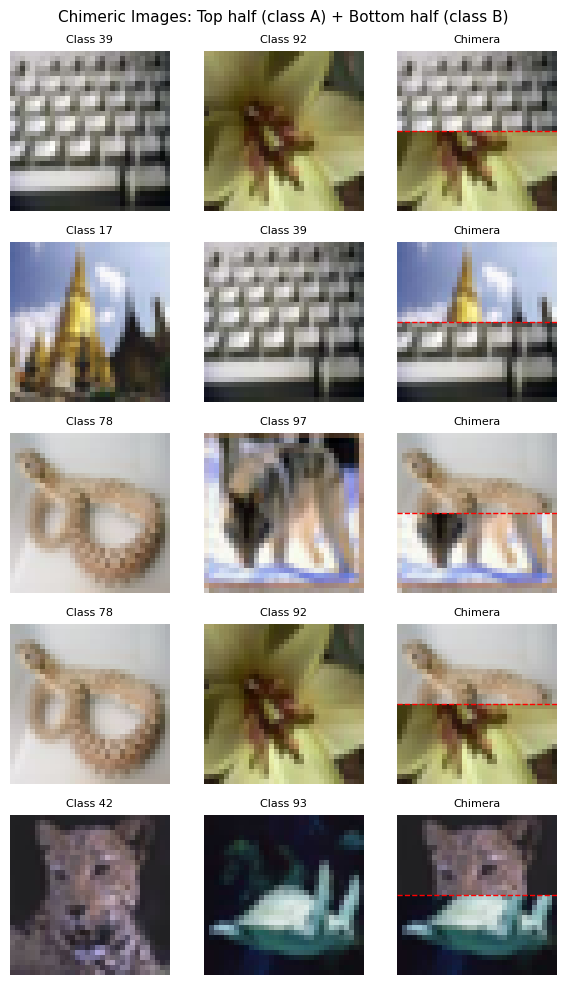

In [37]:
# --- Visualize a few chimeras alongside their source images ---
fig, axes = plt.subplots(N_PAIRS, 3, figsize=(6, 2 * N_PAIRS))
for i, (cls_a, cls_b) in enumerate(class_pairs):
    idx_a = np.where(test_labels == cls_a)[0][0]
    idx_b = np.where(test_labels == cls_b)[0][0]
    chimera = make_chimera(test_images[idx_a], test_images[idx_b])

    for j, (img, title) in enumerate([
        (test_images[idx_a], f"Class {cls_a}"),
        (test_images[idx_b], f"Class {cls_b}"),
        (chimera, "Chimera"),
    ]):
        ax = axes[i, j]
        ax.imshow(img.reshape(IMG_C, IMG_H, IMG_W).transpose(1, 2, 0).clip(0, 1))
        ax.set_title(title, fontsize=8)
        ax.axis("off")
        if j == 0:
            # Draw horizontal line at the splice point
            axes[i, 2].axhline(HALF_H - 0.5, color="red", linewidth=1, linestyle="--")

plt.suptitle("Chimeric Images: Top half (class A) + Bottom half (class B)", fontsize=11)
plt.tight_layout()
plt.show()

In [38]:
# --- Embed chimeras with all 3 models ---
chimera_embs = {
    "LLA": lla_cnn.embed(chimera_images),
    "UG-I": model_ugi.embed(chimera_images),
    "UG-A": model_uga.embed(chimera_images),
}

# Compute class centers from test embeddings
class_centers = {}  # {model_name: {class_label: mean_embedding}}
class_mean_vars = {}  # {model_name: {class_label: mean_variance}}
for name, emb in all_embs:
    class_centers[name] = {}
    class_mean_vars[name] = {}
    for c in unique_classes:
        mask = test_labels == c
        class_centers[name][c] = emb.mean[mask].mean(axis=0)
        class_mean_vars[name][c] = emb.variance[mask].mean(axis=0)

# Compute intra-class variance statistics (baseline for comparison)
intra_class_total_var = {}  # {model_name: array of total variances for all test samples}
for name, emb in all_embs:
    intra_class_total_var[name] = emb.variance.sum(axis=1)

print("Chimera embeddings computed.")
for name, emb in chimera_embs.items():
    print(f"  {name:6s}  mean {emb.mean.shape}, var {emb.variance.shape}")

Chimera embeddings computed.
  LLA     mean (50, 128), var (50, 128)
  UG-I    mean (50, 128), var (50, 128)
  UG-A    mean (50, 128), var (50, 128)


In [39]:
# --- Analysis: Chimera position and variance ---

# 1. For each chimera, compute L2 distance to class A center and class B center
# 2. Compare chimera total variance to intra-class total variance

print(f"{'Model':6s}  {'Pair':>12s}  {'dist_A':>8s}  {'dist_B':>8s}  {'chimera_var':>12s}  "
      f"{'classA_var':>11s}  {'classB_var':>11s}  {'ratio_A':>8s}  {'ratio_B':>8s}")
print("-" * 105)

chimera_stats = {name: [] for name in ["LLA", "UG-I", "UG-A"]}

for name in ["LLA", "UG-I", "UG-A"]:
    c_emb = chimera_embs[name]
    for i, (cls_a, cls_b) in enumerate(class_pairs):
        # Indices for this pair's chimeras
        start = i * N_EXAMPLES_PER_PAIR
        end = start + N_EXAMPLES_PER_PAIR

        # Mean over chimeras for this pair
        chimera_mean = c_emb.mean[start:end].mean(axis=0)
        chimera_var_total = c_emb.variance[start:end].sum(axis=1).mean()

        # Distances to class centers
        center_a = class_centers[name][cls_a]
        center_b = class_centers[name][cls_b]
        dist_a = np.linalg.norm(chimera_mean - center_a)
        dist_b = np.linalg.norm(chimera_mean - center_b)

        # Intra-class variance for comparison
        mask_a = test_labels == cls_a
        mask_b = test_labels == cls_b
        var_a = intra_class_total_var[name][mask_a].mean()
        var_b = intra_class_total_var[name][mask_b].mean()

        ratio_a = chimera_var_total / var_a if var_a > 0 else float('inf')
        ratio_b = chimera_var_total / var_b if var_b > 0 else float('inf')

        chimera_stats[name].append({
            "cls_a": cls_a, "cls_b": cls_b,
            "dist_a": dist_a, "dist_b": dist_b,
            "chimera_var": chimera_var_total,
            "var_a": var_a, "var_b": var_b,
            "ratio_a": ratio_a, "ratio_b": ratio_b,
        })

        print(f"{name:6s}  ({cls_a:3d},{cls_b:3d})  {dist_a:8.3f}  {dist_b:8.3f}  "
              f"{chimera_var_total:12.4f}  {var_a:11.4f}  {var_b:11.4f}  "
              f"{ratio_a:8.2f}x  {ratio_b:8.2f}x")
    print()

Model           Pair    dist_A    dist_B   chimera_var   classA_var   classB_var   ratio_A   ratio_B
---------------------------------------------------------------------------------------------------------
LLA     ( 39, 92)     2.810     0.850        2.2916       1.5543       1.9854      1.47x      1.15x
LLA     ( 17, 39)     1.644     1.511        3.0910       1.8169       1.5543      1.70x      1.99x
LLA     ( 78, 97)     0.606     1.661        1.3895       1.5052       1.5103      0.92x      0.92x
LLA     ( 78, 92)     1.567     1.301        2.1951       1.5052       1.9854      1.46x      1.11x
LLA     ( 42, 93)     1.027     0.684        1.8486       1.4349       1.4689      1.29x      1.26x

UG-I    ( 39, 92)     2.810     0.850        0.7068       0.6882       0.7139      1.03x      0.99x
UG-I    ( 17, 39)     1.644     1.511        0.6690       0.6612       0.6882      1.01x      0.97x
UG-I    ( 78, 97)     0.606     1.661        0.6834       0.6930       0.6912      0.99x    

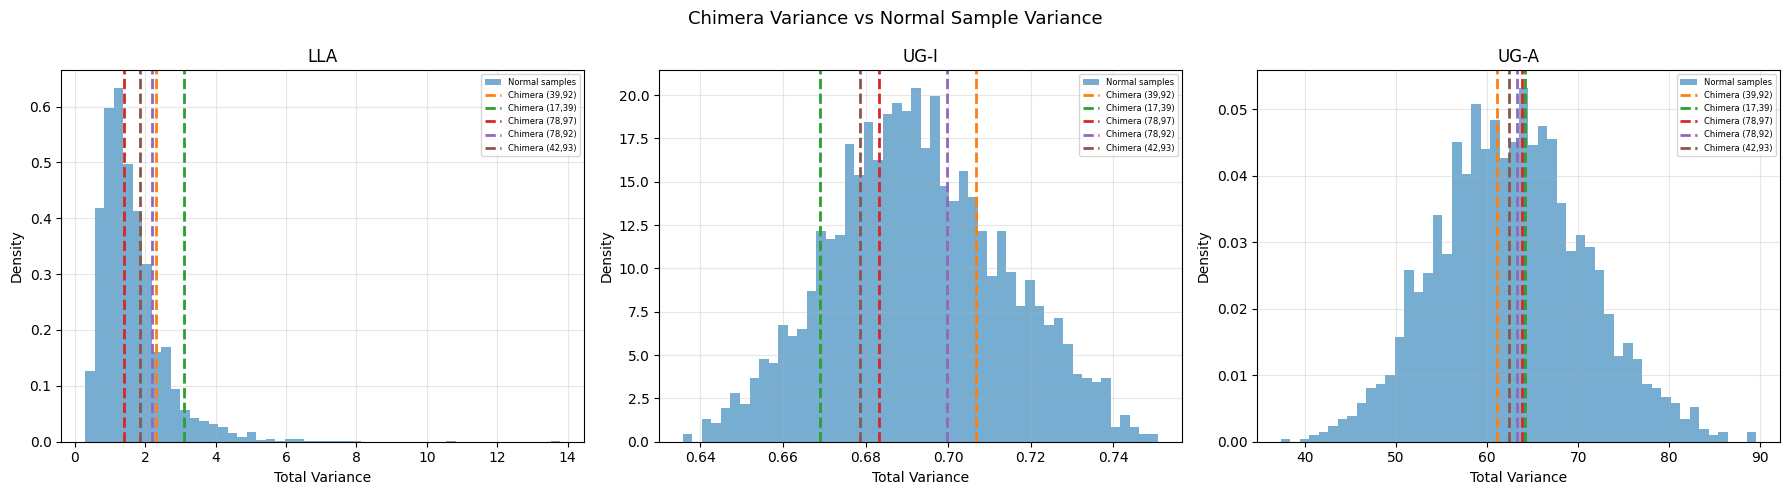

In [40]:
# --- Variance comparison: chimeras vs normal samples ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, name in enumerate(["LLA", "UG-I", "UG-A"]):
    ax = axes[ax_idx]
    c_emb = chimera_embs[name]

    # Intra-class total variances (histogram)
    normal_vars = intra_class_total_var[name]
    chimera_vars = c_emb.variance.sum(axis=1)

    ax.hist(normal_vars, bins=50, alpha=0.6, label="Normal samples",
            density=True, color="C0")
    for j, (cls_a, cls_b) in enumerate(class_pairs):
        start = j * N_EXAMPLES_PER_PAIR
        end = start + N_EXAMPLES_PER_PAIR
        pair_vars = chimera_vars[start:end]
        ax.axvline(pair_vars.mean(), color=f"C{j+1}", linestyle="--", linewidth=2,
                   label=f"Chimera ({cls_a},{cls_b})")

    ax.set_xlabel("Total Variance")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}")
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Chimera Variance vs Normal Sample Variance", fontsize=13)
plt.tight_layout()
plt.show()

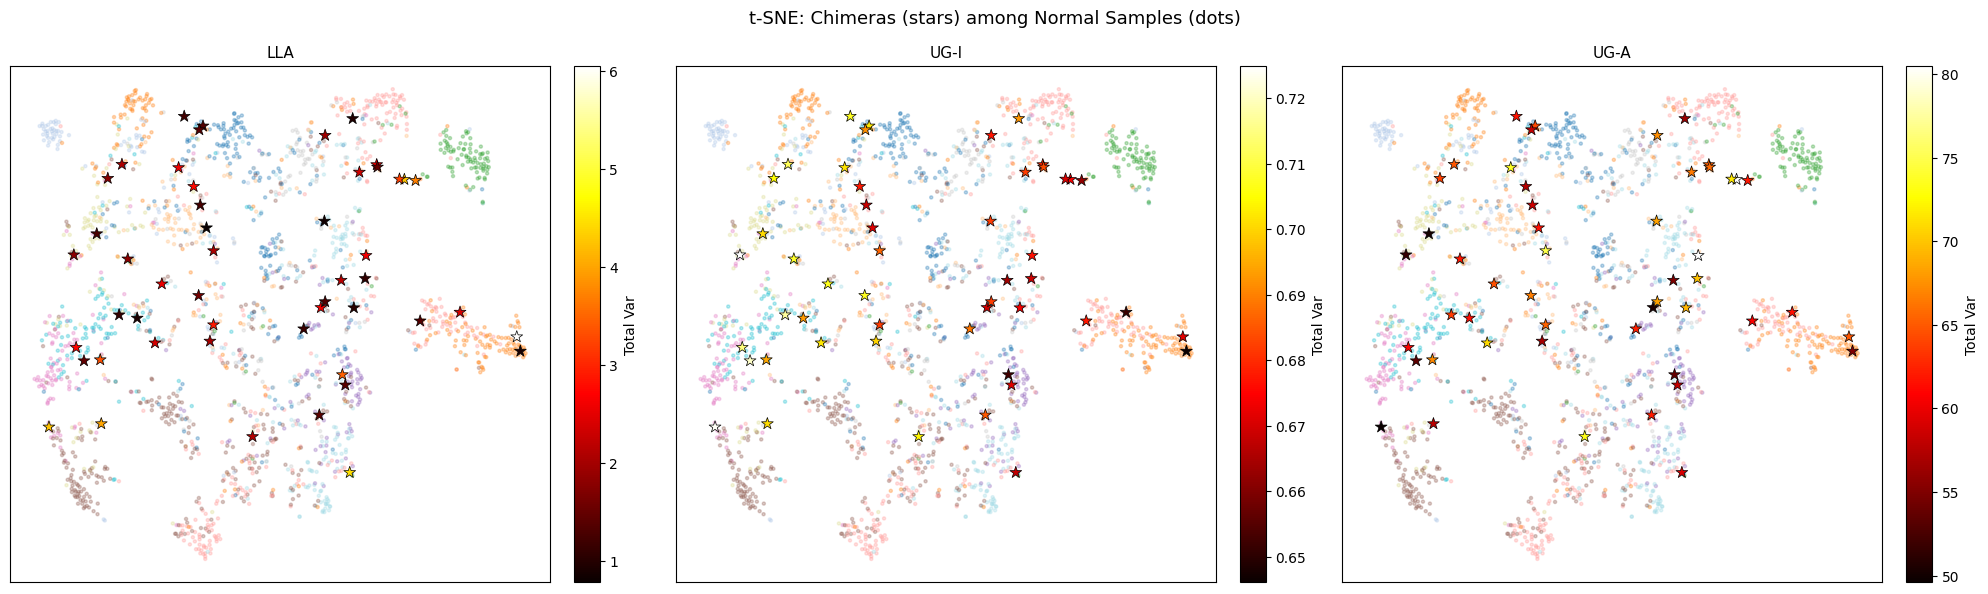

In [41]:
# --- Embedding position: t-SNE of chimeras among normal samples ---
from sklearn.manifold import TSNE

# Use a subset of test samples + all chimeras for t-SNE
N_VIS = 2000
rng_vis = np.random.RandomState(SEED)
vis_idx = rng_vis.choice(len(test_labels), N_VIS, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax_idx, name in enumerate(["LLA", "UG-I", "UG-A"]):
    ax = axes[ax_idx]
    emb = dict(all_embs)[name]
    c_emb = chimera_embs[name]

    # Combine: subset of normal + all chimeras
    combined_means = np.concatenate([emb.mean[vis_idx], c_emb.mean], axis=0)
    combined_vars = np.concatenate([emb.variance[vis_idx], c_emb.variance], axis=0)

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    coords = tsne.fit_transform(combined_means)

    n_normal = len(vis_idx)
    n_chimera = len(chimera_images)

    # Plot normal samples (colored by class)
    ax.scatter(coords[:n_normal, 0], coords[:n_normal, 1],
               c=test_labels[vis_idx], cmap="tab20", s=5, alpha=0.3)

    # Plot chimeras (stars, colored by total variance)
    chimera_total_var = combined_vars[n_normal:].sum(axis=1)
    sc = ax.scatter(coords[n_normal:, 0], coords[n_normal:, 1],
                    c=chimera_total_var, cmap="hot", s=80, marker="*",
                    edgecolors="black", linewidths=0.5, zorder=5)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Total Var")

    ax.set_title(f"{name}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("t-SNE: Chimeras (stars) among Normal Samples (dots)", fontsize=13)
plt.tight_layout()
plt.show()

In [42]:
# --- Summary: mean variance ratio (chimera / normal) per model ---
print("=== Chimera Variance Summary ===")
print(f"{'Model':6s}  {'Normal (mean)':>14s}  {'Chimera (mean)':>15s}  {'Ratio':>8s}")
print("-" * 55)

for name in ["LLA", "UG-I", "UG-A"]:
    normal_mean = intra_class_total_var[name].mean()
    chimera_mean = chimera_embs[name].variance.sum(axis=1).mean()
    ratio = chimera_mean / normal_mean if normal_mean > 0 else float('inf')
    print(f"{name:6s}  {normal_mean:14.4f}  {chimera_mean:15.4f}  {ratio:7.2f}x")

print("\nA ratio > 1 means the model assigns higher uncertainty to chimeric inputs.")
print("This is the desired behavior: ambiguous inputs should have higher variance.")

=== Chimera Variance Summary ===
Model    Normal (mean)   Chimera (mean)     Ratio
-------------------------------------------------------
LLA             1.6382           2.1632     1.32x
UG-I            0.6927           0.6875     0.99x
UG-A           62.7936          62.9653     1.00x

A ratio > 1 means the model assigns higher uncertainty to chimeric inputs.
This is the desired behavior: ambiguous inputs should have higher variance.
